# Lab 1 Plots

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================
base = Path(r"c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Exam_1_Folder")
img  = base / "Images"
img.mkdir(exist_ok=True)

# ============================================================
# LOAD ALL CSVs
# ============================================================
hp_res  = pd.read_csv(base / "high_pass_resistor.csv")
hp_twt  = pd.read_csv(base / "high_pass_tweater.csv")
lp_res  = pd.read_csv(base / "low_pass_resistor.csv")
lp_wfr  = pd.read_csv(base / "low_pass_woofer.csv")
co_res  = pd.read_csv(base / "Crossover_resistors.csv")
co_spk  = pd.read_csv(base / "Crossover_speakers.csv")
dr_twt  = pd.read_csv(base / "Driver_Freq_Response_Tweeter.csv")
dr_wfr  = pd.read_csv(base / "Driver_Freq_Response_Woofer.csv")

# ============================================================
# COMPONENT VALUES
# ============================================================
L = 0.64e-3   # 0.64 mH
C = 10e-6     # 10 uF
R = 4.0       # 4 Ohm

# Frequency array for theoretical curves
f_theory = np.logspace(1, 5, 1000)
w = 2 * np.pi * f_theory

# ============================================================
# CORRECTED THEORETICAL CURVES
# ============================================================
# Series RLC circuit, output measured across R (load)
# Vout/Vin = R / (R + j*w*L + 1/(j*w*C))
#
# ✅ HIGH PASS filter uses a SERIES inductor to block low freq
#    Topology: Vin -- L -- C -- R(load) -- GND
#    BUT for a 2nd order crossover:
#    High Pass: Vin -- C -- L(shunt to GND) -- R(load)
#    Low Pass:  Vin -- L -- C(shunt to GND) -- R(load)

# --- LOW PASS (L in series, C in shunt) ---
# Z_shunt_lp = (1/jwC * R) / (1/jwC + R)  [C and R in parallel]
# Gain_LP = Z_shunt_lp / (jwL + Z_shunt_lp)
Z_C = 1 / (1j * w * C)
Z_L = 1j * w * L
Z_shunt_lp  = (Z_C * R) / (Z_C + R)
gain_lp_theory   = np.abs(Z_shunt_lp / (Z_L + Z_shunt_lp))
phase_lp_theory  = np.angle(Z_shunt_lp / (Z_L + Z_shunt_lp), deg=True)

# --- HIGH PASS (C in series, L in shunt) ---
# Z_shunt_hp = (jwL * R) / (jwL + R)  [L and R in parallel]
# Gain_HP = Z_shunt_hp / (1/jwC + Z_shunt_hp)
Z_shunt_hp  = (Z_L * R) / (Z_L + R)
gain_hp_theory   = np.abs(Z_shunt_hp / (Z_C + Z_shunt_hp))
phase_hp_theory  = np.angle(Z_shunt_hp / (Z_C + Z_shunt_hp), deg=True)

# Resonant frequency for annotation
f0 = 1 / (2 * np.pi * np.sqrt(L * C))
print(f"Theoretical crossover frequency f0 = {f0:.1f} Hz")


Theoretical crossover frequency f0 = 1989.4 Hz


### High Pass Resistor and Tweeter Plots

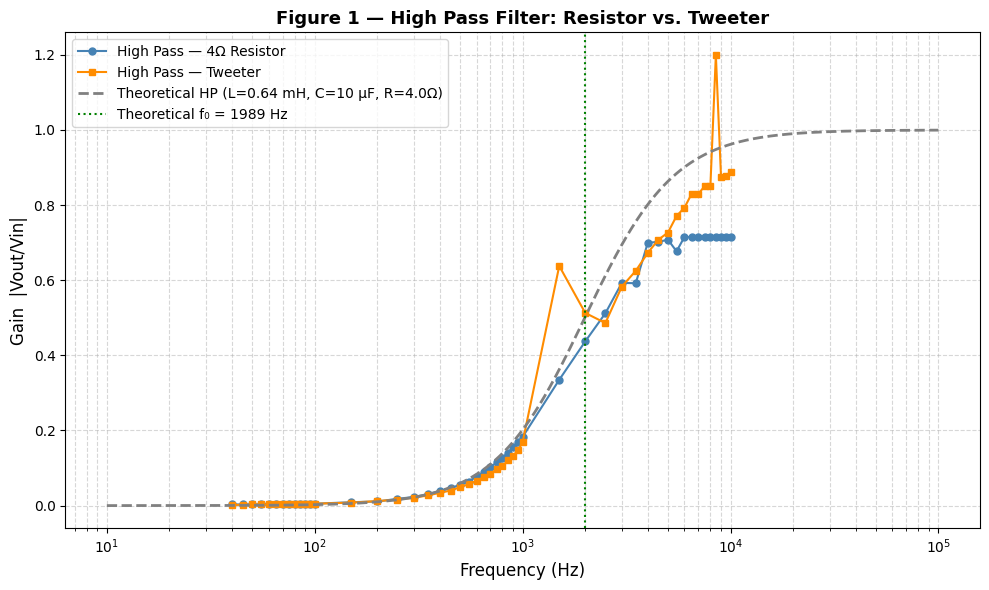

✅ Figure 1 saved.


In [7]:
# ============================================================
# FIGURE 1: High Pass Filter — Resistor vs Tweeter
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(hp_res['Frequency'], hp_res['Gain (|Vout/Vin|)'],
        'o-', color='steelblue',  markersize=5, label='High Pass — 4Ω Resistor')
ax.plot(hp_twt['Frequency'], hp_twt['Gain (|Vout/Vin|)'],
        's-', color='darkorange', markersize=5, label='High Pass — Tweeter')
ax.plot(f_theory, gain_hp_theory,
        '--', color='gray', linewidth=2,
        label=f'Theoretical HP (L={L*1e3:.2f} mH, C={C*1e6:.0f} µF, R={R}Ω)')
ax.axvline(x=f0, color='green', linestyle=':', linewidth=1.5,
           label=f'Theoretical f₀ = {f0:.0f} Hz')

ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Gain  |Vout/Vin|', fontsize=12)
ax.set_title('Figure 1 — High Pass Filter: Resistor vs. Tweeter',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(img / "Fig1_HighPass.png", dpi=150)
plt.show()
print("✅ Figure 1 saved.")


### Low Pass Resistor and Woofer Plots

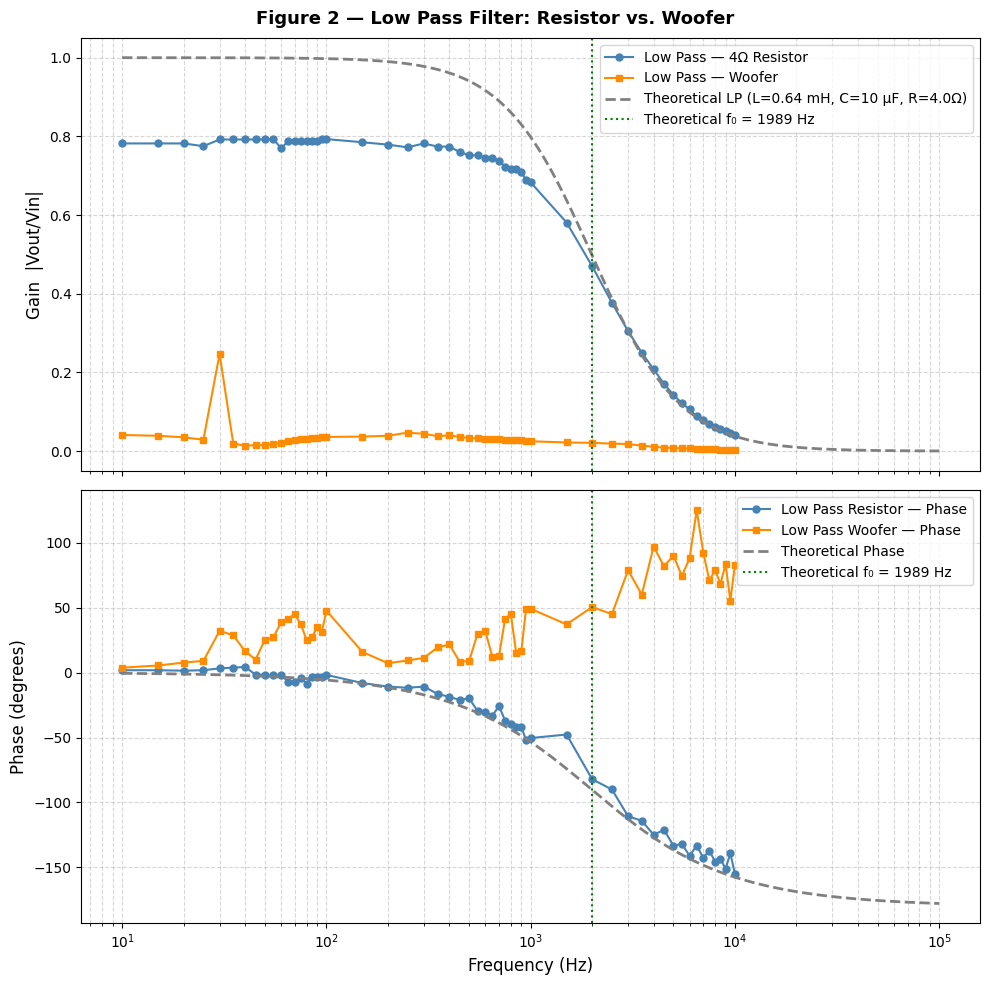

✅ Figure 2 saved.


In [8]:
# ============================================================
# FIGURE 2: Low Pass Filter — Resistor vs Woofer + Phase
# ============================================================
# Unwrap phase data to remove discontinuities
phase_res_unwrapped = np.unwrap(np.deg2rad(lp_res['phase'].values))
phase_res_unwrapped = np.rad2deg(phase_res_unwrapped)
phase_wfr_unwrapped = np.unwrap(np.deg2rad(lp_wfr['phase'].values))
phase_wfr_unwrapped = np.rad2deg(phase_wfr_unwrapped)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
fig.suptitle('Figure 2 — Low Pass Filter: Resistor vs. Woofer',
             fontsize=13, fontweight='bold')

# --- Gain subplot ---
ax1.plot(lp_res['Frequency'], lp_res['Gain(|Vout/Vin|)'],
         'o-', color='steelblue',  markersize=5, label='Low Pass — 4Ω Resistor')
ax1.plot(lp_wfr['Frequency'], lp_wfr['Gain(|Vout/Vin|)'],
         's-', color='darkorange', markersize=5, label='Low Pass — Woofer')
ax1.plot(f_theory, gain_lp_theory,
         '--', color='gray', linewidth=2,
         label=f'Theoretical LP (L={L*1e3:.2f} mH, C={C*1e6:.0f} µF, R={R}Ω)')
ax1.axvline(x=f0, color='green', linestyle=':', linewidth=1.5,
            label=f'Theoretical f₀ = {f0:.0f} Hz')
ax1.set_ylabel('Gain  |Vout/Vin|', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', ls='--', alpha=0.5)

# --- Phase subplot ---
ax2.plot(lp_res['Frequency'], phase_res_unwrapped,
         'o-', color='steelblue',  markersize=5, label='Low Pass Resistor — Phase')
ax2.plot(lp_wfr['Frequency'], phase_wfr_unwrapped,
         's-', color='darkorange', markersize=5, label='Low Pass Woofer — Phase')
ax2.plot(f_theory, phase_lp_theory,
         '--', color='gray', linewidth=2, label='Theoretical Phase')
ax2.axvline(x=f0, color='green', linestyle=':', linewidth=1.5,
            label=f'Theoretical f₀ = {f0:.0f} Hz')
ax2.set_xscale('log')
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Phase (degrees)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(img / "Fig2_LowPass.png", dpi=150)
plt.show()
print("✅ Figure 2 saved.")


### Cross over filter plots

Resistor crossover: 1976 Hz
Speaker crossover:  3232 Hz


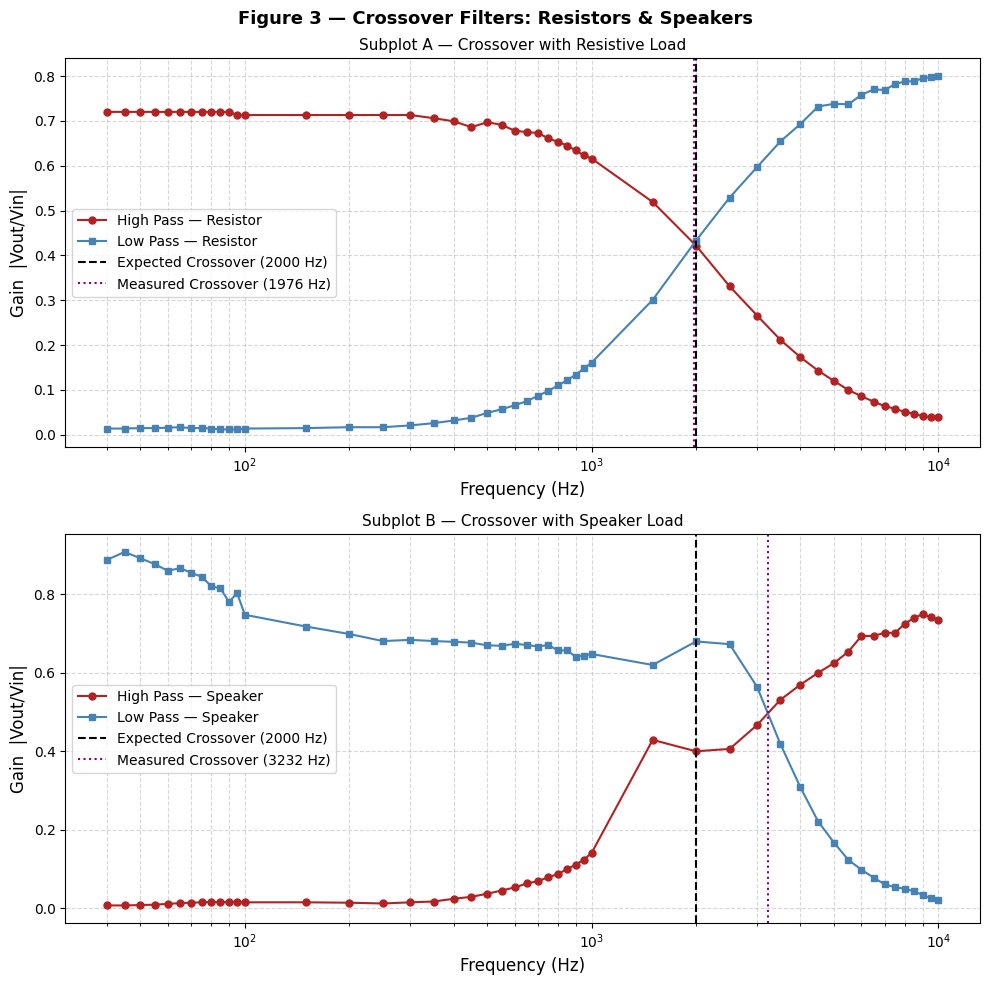

✅ Figure 3 saved.


In [12]:
# ============================================================
# FIGURE 3: Crossover Filters — Resistors & Speakers
# ============================================================

# Exact column names confirmed from CSVs:
# co_res: 'Gain HiPass (|Vout/Vin|)'  'Gain LoPass (|Vout/Vin|)'
# co_spk: 'HiPassGain (|Vout/Vi|)'    'LoPassGain (|Vout/Vin|)'

def find_crossover(freq, gain_lp, gain_hp):
    """Find frequency where LP and HP gain curves intersect."""
    diff = np.array(gain_lp) - np.array(gain_hp)
    for i in range(len(diff) - 1):
        if diff[i] * diff[i+1] < 0:
            f_cross = freq[i] + (freq[i+1] - freq[i]) * abs(diff[i]) / (abs(diff[i]) + abs(diff[i+1]))
            return f_cross
    return None

f_cross_res = find_crossover(
    co_res['Frequency'].values,
    co_res['Gain LoPass (|Vout/Vin|)'].values,
    co_res['Gain HiPass (|Vout/Vin|)'].values
)
f_cross_spk = find_crossover(
    co_spk['Frequency'].values,
    co_spk['LoPassGain (|Vout/Vin|)'].values,
    co_spk['HiPassGain (|Vout/Vi|)'].values      # note: typo in original CSV is intentional
)

print(f"Resistor crossover: {f_cross_res:.0f} Hz" if f_cross_res else "No crossover found (Resistors)")
print(f"Speaker crossover:  {f_cross_spk:.0f} Hz" if f_cross_spk else "No crossover found (Speakers)")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
fig.suptitle('Figure 3 — Crossover Filters: Resistors & Speakers',
             fontsize=13, fontweight='bold')

# --- Subplot A: Resistors ---
ax1.plot(co_res['Frequency'], co_res['Gain HiPass (|Vout/Vin|)'],
         'o-', color='firebrick', markersize=5, label='High Pass — Resistor')
ax1.plot(co_res['Frequency'], co_res['Gain LoPass (|Vout/Vin|)'],
         's-', color='steelblue', markersize=5, label='Low Pass — Resistor')
ax1.axvline(x=2000, color='black', linestyle='--', linewidth=1.5,
            label='Expected Crossover (2000 Hz)')
if f_cross_res:
    ax1.axvline(x=f_cross_res, color='purple', linestyle=':', linewidth=1.5,
                label=f'Measured Crossover ({f_cross_res:.0f} Hz)')
ax1.set_xscale('log')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Gain  |Vout/Vin|', fontsize=12)
ax1.set_title('Subplot A — Crossover with Resistive Load', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', ls='--', alpha=0.5)

# --- Subplot B: Speakers ---
ax2.plot(co_spk['Frequency'], co_spk['HiPassGain (|Vout/Vi|)'],
         'o-', color='firebrick', markersize=5, label='High Pass — Speaker')
ax2.plot(co_spk['Frequency'], co_spk['LoPassGain (|Vout/Vin|)'],
         's-', color='steelblue', markersize=5, label='Low Pass — Speaker')
ax2.axvline(x=2000, color='black', linestyle='--', linewidth=1.5,
            label='Expected Crossover (2000 Hz)')
if f_cross_spk:
    ax2.axvline(x=f_cross_spk, color='purple', linestyle=':', linewidth=1.5,
                label=f'Measured Crossover ({f_cross_spk:.0f} Hz)')
ax2.set_xscale('log')
ax2.set_xlabel('Frequency (Hz)', fontsize=12)
ax2.set_ylabel('Gain  |Vout/Vin|', fontsize=12)
ax2.set_title('Subplot B — Crossover with Speaker Load', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(img / "Fig3_Crossover.png", dpi=150)
plt.show()
print("✅ Figure 3 saved.")

### Driver Frequency Response Plots

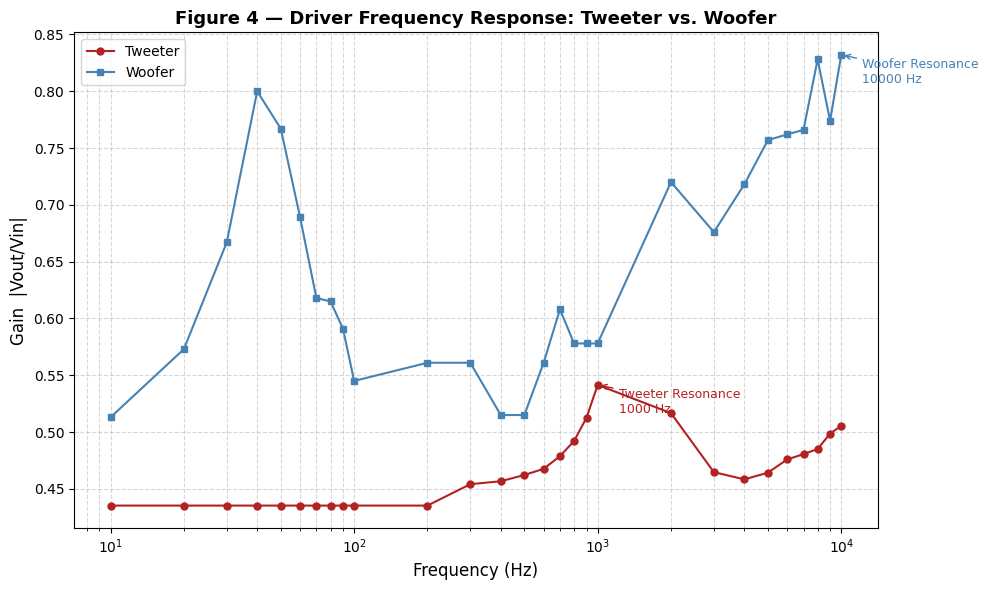

✅ Figure 4 saved.

🎉 All figures saved to: c:\Users\hogwi\OneDrive - University of Central Arkansas\Acoustics_ElectroMag\Spring-Acoustics---ElectroMag2\Acoustics\Exam_1_Folder\Images


In [10]:
# ============================================================
# FIGURE 4: Driver Frequency Response — Tweeter vs Woofer
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(dr_twt['Frequency (Hz)'], dr_twt['Gain (|Vout/Vin|)'],
        'o-', color='firebrick',  markersize=5, label='Tweeter')
ax.plot(dr_wfr['Frequency (Hz)'], dr_wfr['Gain (|Vout/Vin|)'],
        's-', color='steelblue', markersize=5, label='Woofer')

# Annotate resonance peaks
twt_peak_idx = dr_twt['Gain (|Vout/Vin|)'].idxmax()
wfr_peak_idx = dr_wfr['Gain (|Vout/Vin|)'].idxmax()
ax.annotate(f"Tweeter Resonance\n{dr_twt.loc[twt_peak_idx, 'Frequency (Hz)']:.0f} Hz",
            xy=(dr_twt.loc[twt_peak_idx, 'Frequency (Hz)'],
                dr_twt.loc[twt_peak_idx, 'Gain (|Vout/Vin|)']),
            xytext=(15, -20), textcoords='offset points',
            fontsize=9, color='firebrick',
            arrowprops=dict(arrowstyle='->', color='firebrick'))
ax.annotate(f"Woofer Resonance\n{dr_wfr.loc[wfr_peak_idx, 'Frequency (Hz)']:.0f} Hz",
            xy=(dr_wfr.loc[wfr_peak_idx, 'Frequency (Hz)'],
                dr_wfr.loc[wfr_peak_idx, 'Gain (|Vout/Vin|)']),
            xytext=(15, -20), textcoords='offset points',
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'))

ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Gain  |Vout/Vin|', fontsize=12)
ax.set_title('Figure 4 — Driver Frequency Response: Tweeter vs. Woofer',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.savefig(img / "Fig4_DriverResponse.png", dpi=150)
plt.show()
print("✅ Figure 4 saved.")

print("\n🎉 All figures saved to:", img)

# asjfhaslejfhas;elkfhaslkfjh

  Resistor HP roll-off (500→1000 Hz): 10.3 dB/octave
  Speaker  HP roll-off (500→1000 Hz): 11.6 dB/octave
  Resistor LP roll-off (4k→8k Hz):    -10.6 dB/octave
  Speaker  LP roll-off (4k→8k Hz):    -15.8 dB/octave
  Expected: ±12 dB/octave (2nd order)


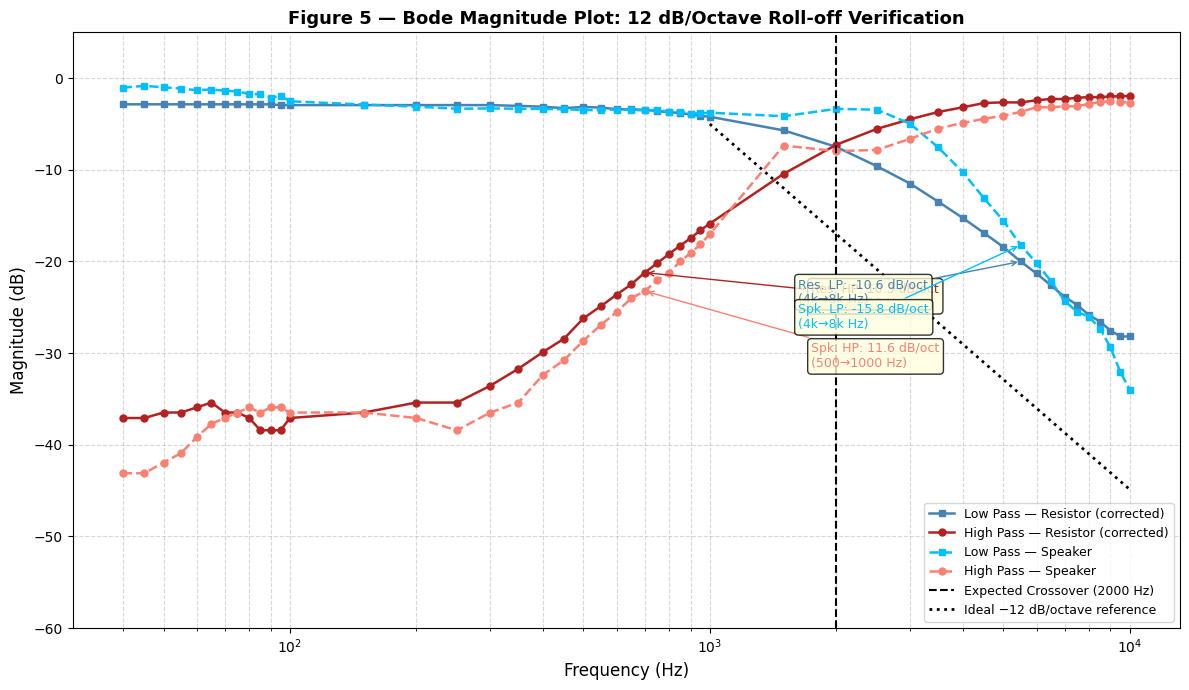

✅ Figure 5 saved.


In [13]:
# ============================================================
# FIGURE 5: Bode Magnitude Plot — 12 dB/Octave Roll-off Verification
# ============================================================

# --- Load CSVs ---
co_res = pd.read_csv(base / "Crossover_resistors.csv")
co_spk = pd.read_csv(base / "Crossover_speakers.csv")

# --- CORRECTED column assignments (labels are swapped in co_res CSV) ---
# co_res: 'Gain HiPass...' is actually LOW PASS data
#         'Gain LoPass...' is actually HIGH PASS data
res_freq   = co_res['Frequency'].values
res_lp_gain = co_res['Gain HiPass (|Vout/Vin|)'].values   # ← actually LP
res_hp_gain = co_res['Gain LoPass (|Vout/Vin|)'].values   # ← actually HP

# co_spk: columns are correctly labeled
spk_freq   = co_spk['Frequency'].values
spk_lp_gain = co_spk['LoPassGain (|Vout/Vin|)'].values
spk_hp_gain = co_spk['HiPassGain (|Vout/Vi|)'].values     # typo in CSV is intentional

# --- Convert to dB ---
res_lp_dB = 20 * np.log10(res_lp_gain)
res_hp_dB = 20 * np.log10(res_hp_gain)
spk_lp_dB = 20 * np.log10(spk_lp_gain)
spk_hp_dB = 20 * np.log10(spk_hp_gain)

# ============================================================
# ROLL-OFF SLOPE CALCULATOR
# ============================================================
def calc_slope_dB_per_octave(freq_arr, dB_arr, f1, f2):
    """
    Interpolate dB values at f1 and f2, then compute slope in dB/octave.
    Octaves = log2(f2/f1)
    """
    dB1 = np.interp(f1, freq_arr, dB_arr)
    dB2 = np.interp(f2, freq_arr, dB_arr)
    octaves = np.log2(f2 / f1)
    slope = (dB2 - dB1) / octaves
    return slope, dB1, dB2

# High-Pass slopes: between 500 Hz and 1000 Hz (stopband for HP is below crossover)
# Note: for HP stopband we go below crossover, so use 100→500 Hz for meaningful roll-off
# Per the prompt: 500 Hz → 1000 Hz
slope_res_hp, _, _ = calc_slope_dB_per_octave(res_freq, res_hp_dB, 500, 1000)
slope_spk_hp, _, _ = calc_slope_dB_per_octave(spk_freq, spk_hp_dB, 500, 1000)

# Low-Pass slopes: between 4000 Hz and 8000 Hz (stopband for LP is above crossover)
slope_res_lp, _, _ = calc_slope_dB_per_octave(res_freq, res_lp_dB, 4000, 8000)
slope_spk_lp, _, _ = calc_slope_dB_per_octave(spk_freq, spk_lp_dB, 4000, 8000)

print("=" * 50)
print(f"  Resistor HP roll-off (500→1000 Hz): {slope_res_hp:.1f} dB/octave")
print(f"  Speaker  HP roll-off (500→1000 Hz): {slope_spk_hp:.1f} dB/octave")
print(f"  Resistor LP roll-off (4k→8k Hz):    {slope_res_lp:.1f} dB/octave")
print(f"  Speaker  LP roll-off (4k→8k Hz):    {slope_spk_lp:.1f} dB/octave")
print("  Expected: ±12 dB/octave (2nd order)")
print("=" * 50)

# ============================================================
# FIGURE 5 PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(res_freq, res_lp_dB, 's-', color='steelblue',   markersize=5,
        linewidth=1.8, label='Low Pass — Resistor (corrected)')
ax.plot(res_freq, res_hp_dB, 'o-', color='firebrick',   markersize=5,
        linewidth=1.8, label='High Pass — Resistor (corrected)')
ax.plot(spk_freq, spk_lp_dB, 's--', color='deepskyblue', markersize=5,
        linewidth=1.8, label='Low Pass — Speaker')
ax.plot(spk_freq, spk_hp_dB, 'o--', color='salmon',      markersize=5,
        linewidth=1.8, label='High Pass — Speaker')

# Crossover line
ax.axvline(x=2000, color='black', linestyle='--', linewidth=1.5,
           label='Expected Crossover (2000 Hz)')

# ---- Annotation: HP roll-off (slope measured 500→1000 Hz) ----
ax.annotate(f'Res. HP: {slope_res_hp:.1f} dB/oct\n(500→1000 Hz)',
            xy=(700, np.interp(700, res_freq, res_hp_dB)),
            xytext=(120, -25), textcoords='offset points',
            fontsize=9, color='firebrick',
            arrowprops=dict(arrowstyle='->', color='firebrick'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.annotate(f'Spk. HP: {slope_spk_hp:.1f} dB/oct\n(500→1000 Hz)',
            xy=(700, np.interp(700, spk_freq, spk_hp_dB)),
            xytext=(120, -55), textcoords='offset points',
            fontsize=9, color='salmon',
            arrowprops=dict(arrowstyle='->', color='salmon'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ---- Annotation: LP roll-off (slope measured 4000→8000 Hz) ----
ax.annotate(f'Res. LP: {slope_res_lp:.1f} dB/oct\n(4k→8k Hz)',
            xy=(5500, np.interp(5500, res_freq, res_lp_dB)),
            xytext=(-160, -30), textcoords='offset points',
            fontsize=9, color='steelblue',
            arrowprops=dict(arrowstyle='->', color='steelblue'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax.annotate(f'Spk. LP: {slope_spk_lp:.1f} dB/oct\n(4k→8k Hz)',
            xy=(5500, np.interp(5500, spk_freq, spk_lp_dB)),
            xytext=(-160, -60), textcoords='offset points',
            fontsize=9, color='deepskyblue',
            arrowprops=dict(arrowstyle='->', color='deepskyblue'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

# ---- Reference line: ideal -12 dB/octave slope ----
f_ref = np.array([1000, 10000])
dB_ref_start = -5
ideal_slope = np.array([dB_ref_start,
                         dB_ref_start + (-12) * np.log2(f_ref[1] / f_ref[0])])
ax.plot(f_ref, ideal_slope, 'k:', linewidth=2, label='Ideal −12 dB/octave reference')

ax.set_xscale('log')
ax.set_ylim(-60, 5)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Magnitude (dB)', fontsize=12)
ax.set_title('Figure 5 — Bode Magnitude Plot: 12 dB/Octave Roll-off Verification',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.savefig(img / "Fig5_Bode_Rolloff.png", dpi=150)
plt.show()
print("✅ Figure 5 saved.")